## Genus /Euler Number / v_2

In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

from GRF import generate_gaussian_random_field

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[14:15:16] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=956151;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=15096;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

In [2]:
from skimage.measure import euler_number

def calculate_genus_from_map(data, threshold):
    """
    Calculate the genus and Euler number of a 2D shape from its map.

    Parameters
    ----------
    data : numpy.ndarray
        2D array representing the map.
    threshold : float
        Threshold value to create a binary mask.

    Returns
    -------
    genus : int
        The genus of the shape.
    euler_num : int
        The Euler characteristic (v2) of the shape.
    """
    mask = data >= threshold
    euler_num = euler_number(mask)
    genus = 1 - euler_num
    return genus, euler_num

In [3]:
def calculate_v2(data, thresholds):
    """
    Calculate the Euler characteristic (v2) for a range of thresholds.

    Parameters
    ----------
    data : numpy.ndarray
        2D array representing the map.
    thresholds : numpy.ndarray
        Array of threshold values.

    Returns
    -------
    euler_chars : list
        List of Euler characteristics for each threshold.
    """
    euler_chars = []
    for threshold in thresholds:
        _, euler_num = calculate_genus_from_map(data, threshold)
        euler_chars.append(euler_num)
    return euler_chars

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

thresholds_OA = np.linspace(threshold_min, threshold_max, 100)
# threshold_max = 1.0e23

# Minkowski
results_OA = calculate_v2(N_H2_OA, thresholds_OA)
results_OB = calculate_v2(N_H2_OB, thresholds_OA)

GRF, _ = generate_gaussian_random_field(512, a=-2)

thresholds_GRF = np.linspace(np.min(GRF), np.max(GRF), 100)

results_GRF = calculate_v2(GRF, thresholds_GRF)

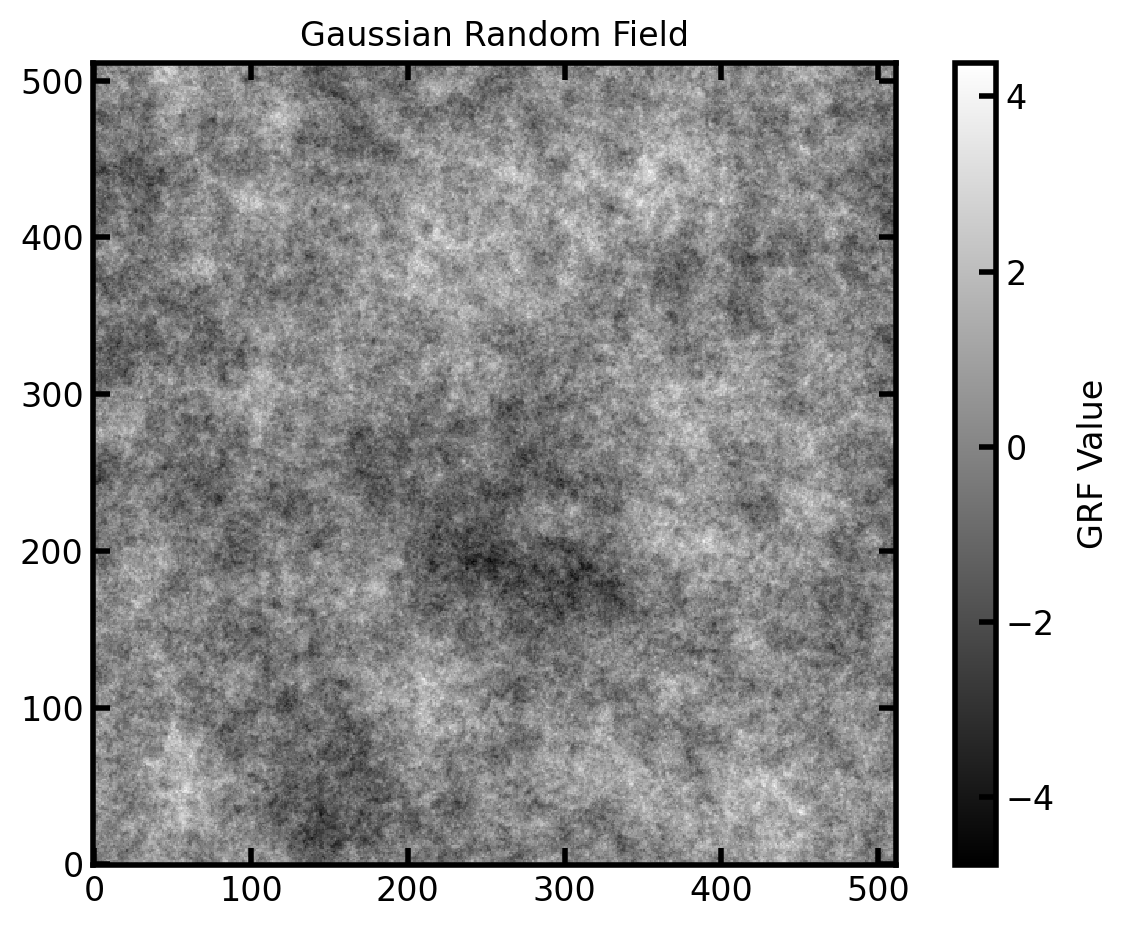

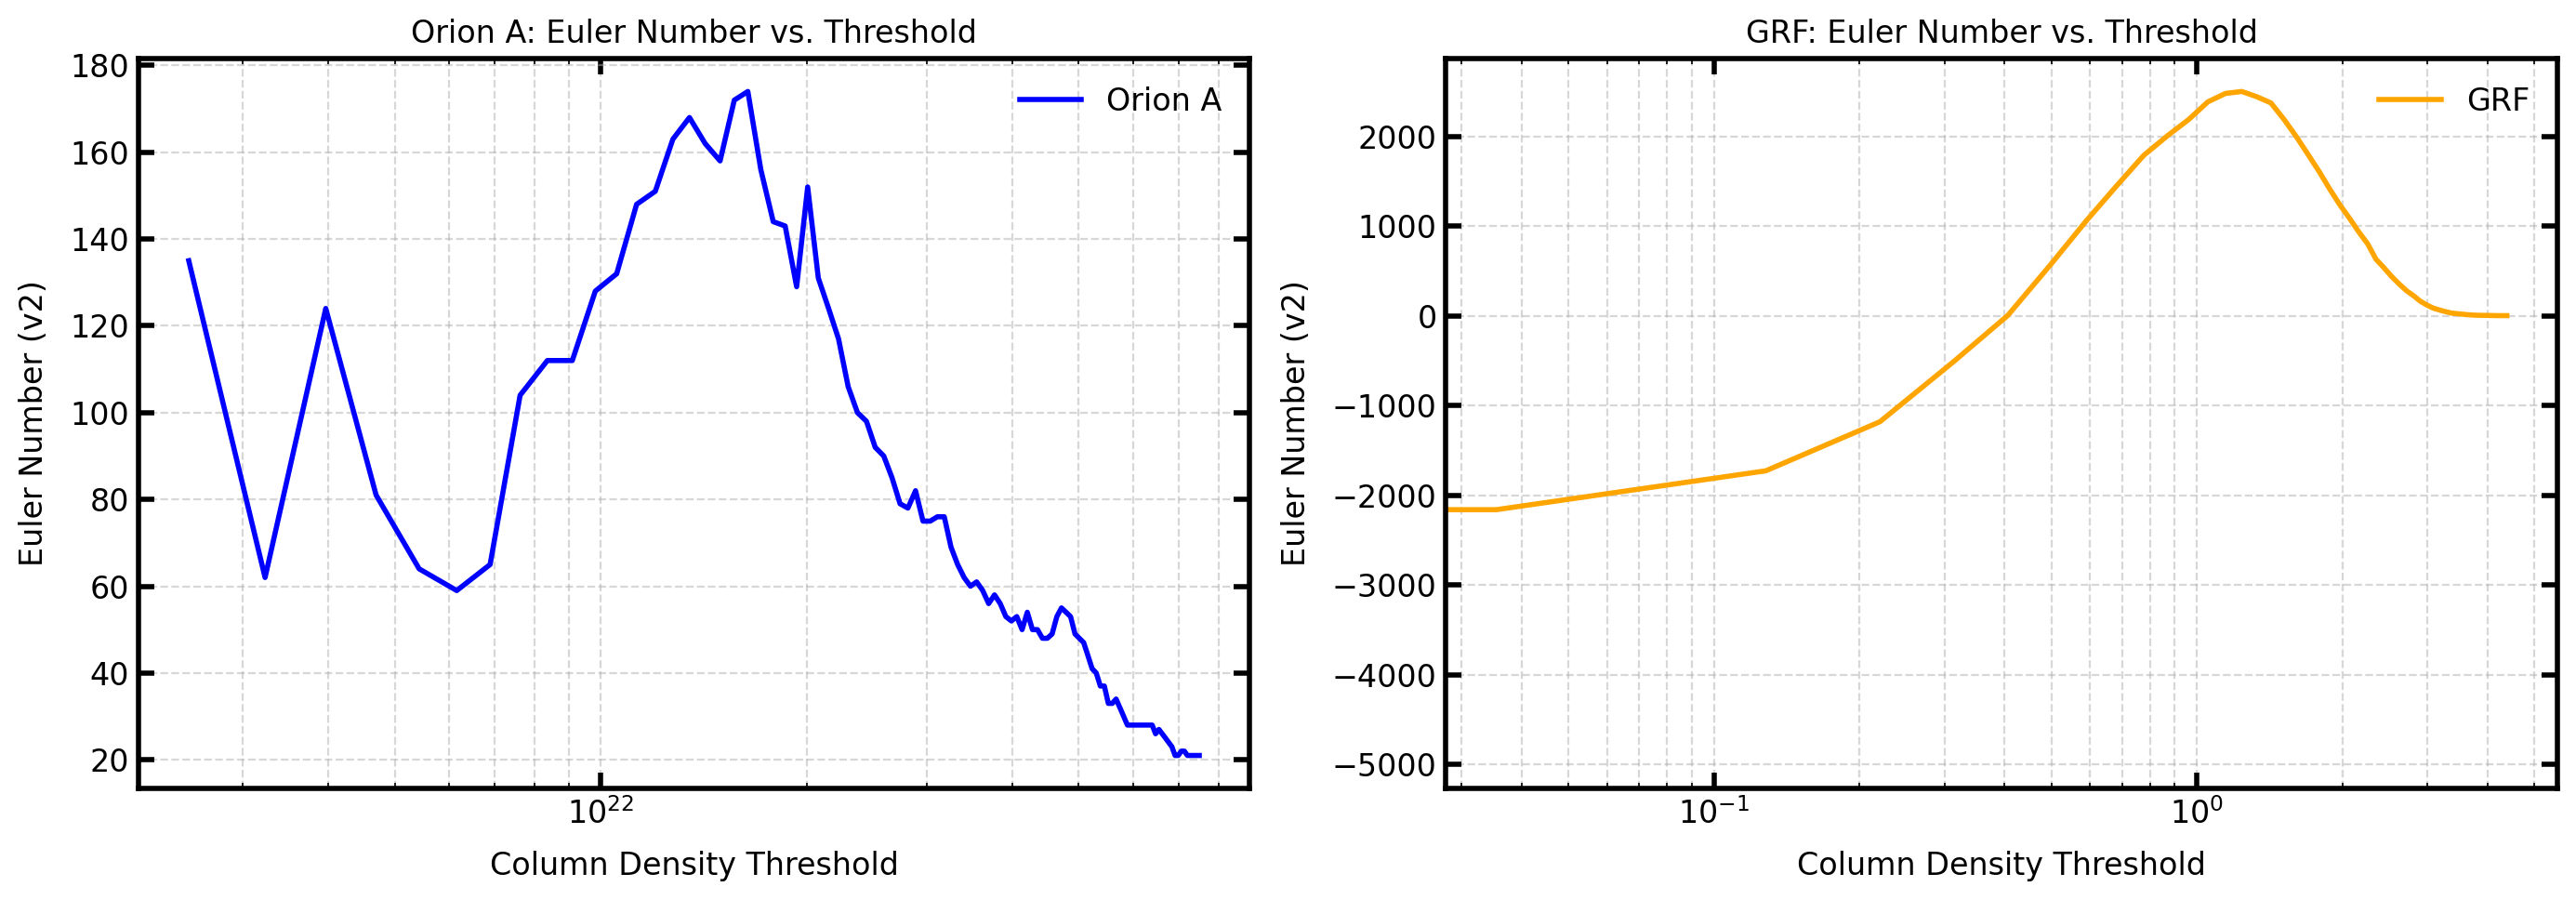

In [4]:
plt.imshow(GRF, cmap='gray', origin='lower')
plt.colorbar(label='GRF Value')
plt.title('Gaussian Random Field')
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

# Orion A
axs[0].plot(thresholds_OA, results_OA, label="Orion A", color="blue")
axs[0].set_xscale("log")
axs[0].set_xlabel("Column Density Threshold")
axs[0].set_ylabel("Euler Number (v2)")
axs[0].set_title("Orion A: Euler Number vs. Threshold")
axs[0].legend()
axs[0].grid(True, which="both", ls="--", alpha=0.5)

# GRF
axs[1].plot(thresholds_GRF, results_GRF, label="GRF", color="orange")
axs[1].set_xscale("log")
axs[1].set_xlabel("Column Density Threshold")
axs[1].set_ylabel("Euler Number (v2)")
axs[1].set_title("GRF: Euler Number vs. Threshold")
axs[1].legend()
axs[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12128\2034756843.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


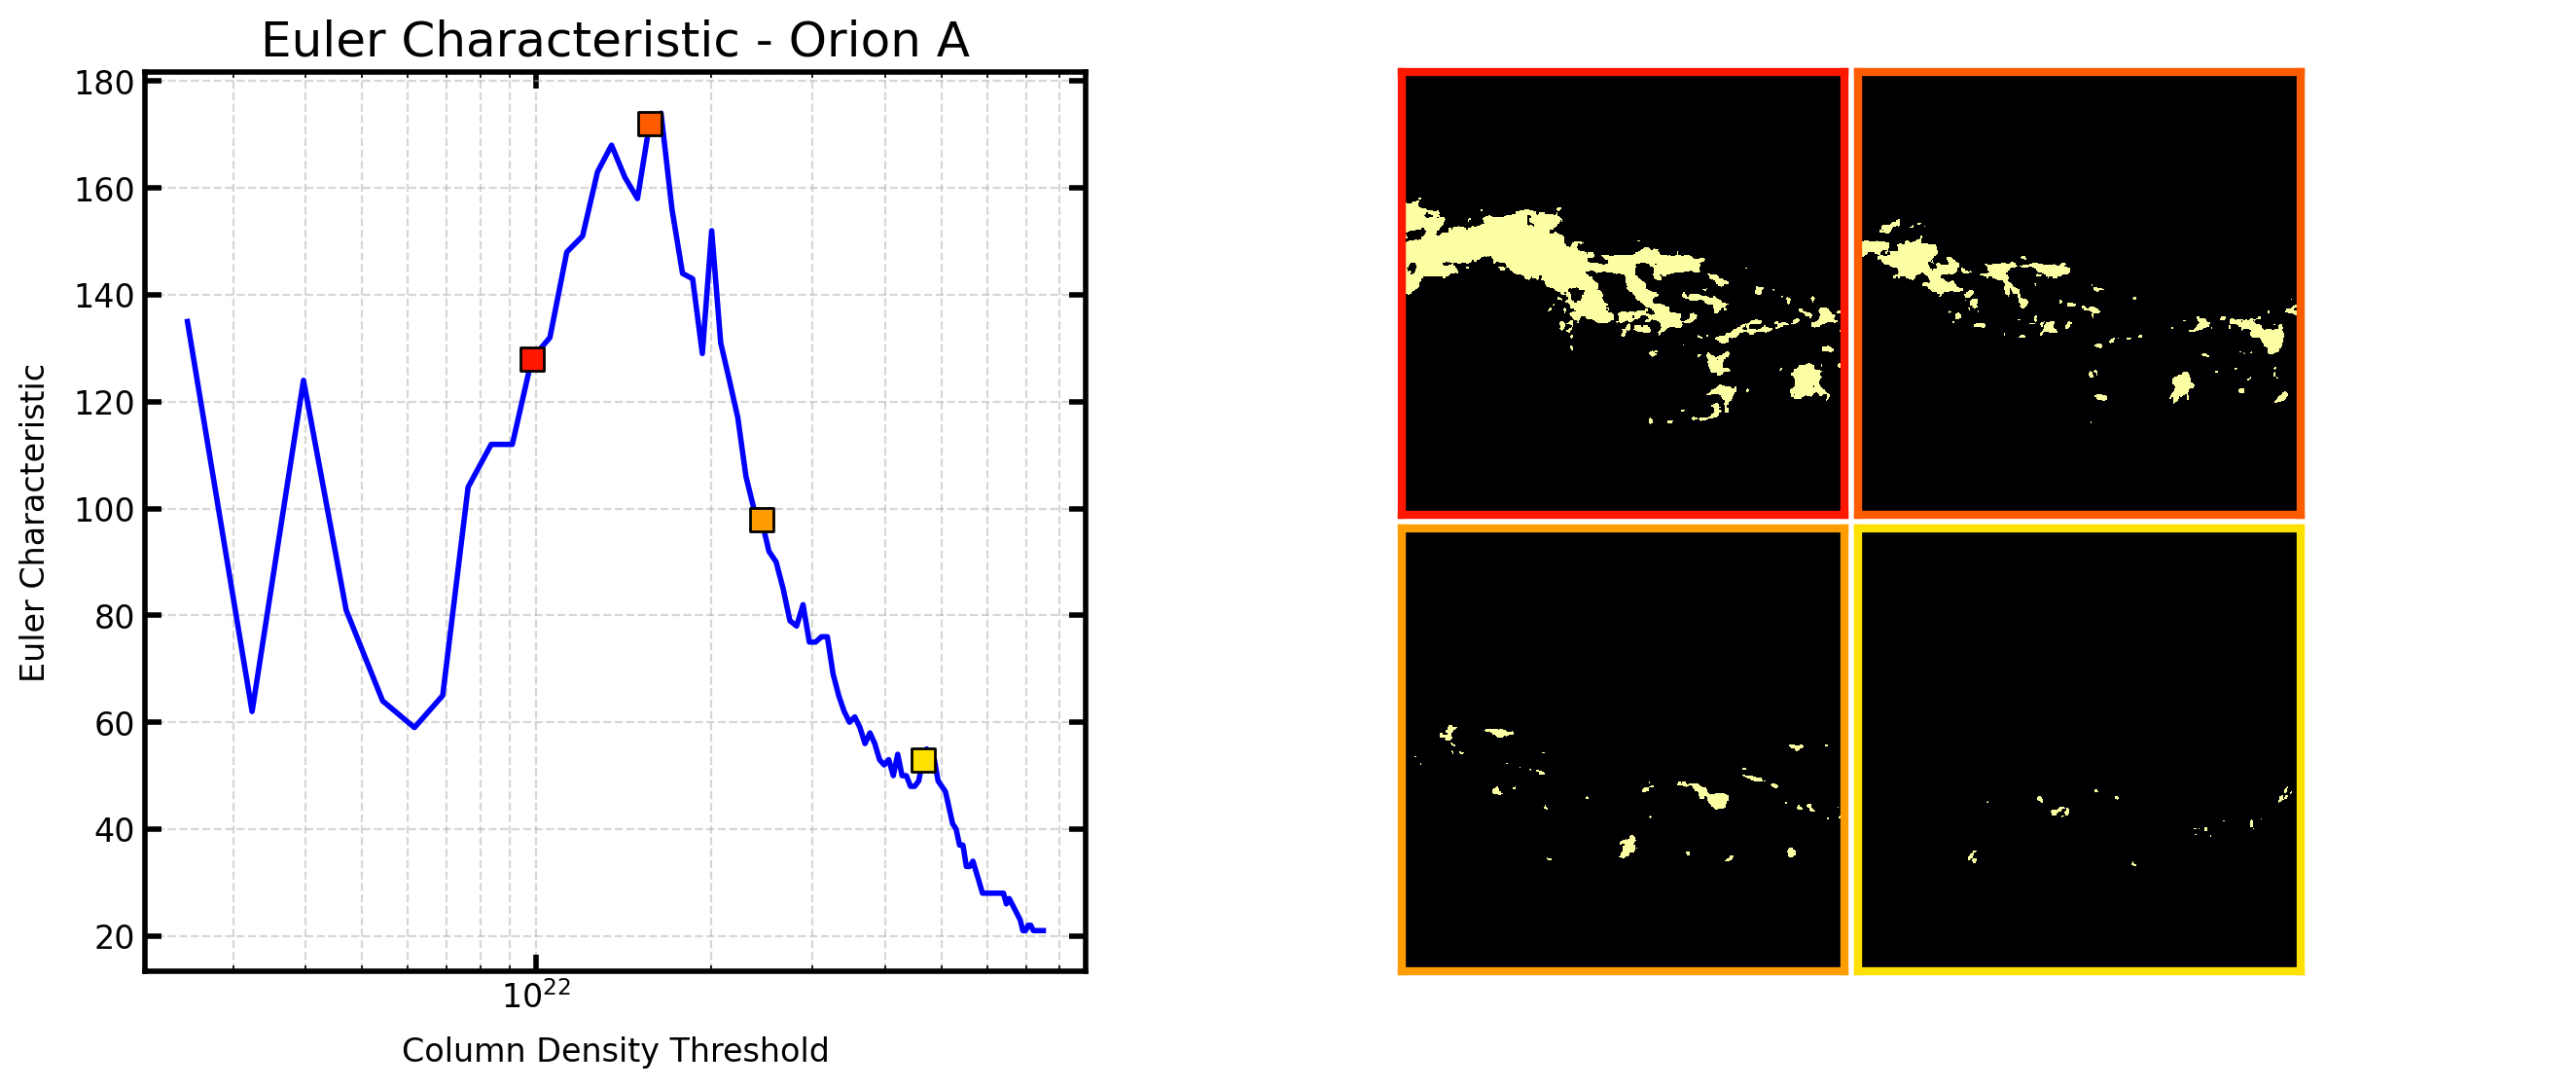

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import ImageGrid

def slice_around_mask_center(mask, zoom_pixels=200):
    """
    Returns a slice around the center of the mask region with a fixed zoom size.
    
    Parameters:
        mask (2D array): Binary mask (e.g., structure >= threshold)
        zoom_pixels (int): Half-width/height of the zoom box in pixels
        
    Returns:
        y_slice, x_slice: slice objects to index the region
    """
    y, x = np.where(mask)
    if len(x) == 0 or len(y) == 0:
        # fallback: center of the full image
        center_y, center_x = mask.shape[0] // 2, mask.shape[1] // 2
    else:
        # center of the structure
        center_y = int(np.mean(y))
        center_x = int(np.mean(x))

    y_min = max(center_y - zoom_pixels, 0)
    y_max = min(center_y + zoom_pixels, mask.shape[0])
    x_min = max(center_x - zoom_pixels, 0)
    x_max = min(center_x + zoom_pixels, mask.shape[1])

    return slice(y_min, y_max), slice(x_min, x_max)


def plot_euler_and_structures(data, thresholds, euler_results, title_prefix, example_threshold_indices, cmap='gray'):
    fig = plt.figure(figsize=(16, 6))

    min_value = np.percentile(data, 2)  # 2nd percentile
    max_value = np.percentile(data, 98)  # 98th percentile

    # Create a gridspec to place the main plot and image grid
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5], wspace=0.05)

    # Left: Euler number vs threshold
    ax_curve = fig.add_subplot(gs[0])
    ax_curve.plot(thresholds, euler_results, color='blue')
    ax_curve.set_xscale("log")
    ax_curve.set_xlabel("Column Density Threshold")
    ax_curve.set_ylabel("Euler Characteristic")
    ax_curve.set_title(f"Euler Characteristic - {title_prefix}", fontsize=18)
    ax_curve.grid(True, which="both", ls="--", alpha=0.5)

    # Mark the selected thresholds
    colors = plt.cm.hot(np.linspace(0.4, 0.7, len(example_threshold_indices)))
    for idx, color in zip(example_threshold_indices, colors):
        ax_curve.scatter(thresholds[idx], euler_results[idx], color=color, s=70, edgecolor='black', zorder=5, marker="s")

    # Right: 2x2 grid of structure examples
    ax_grid_container = fig.add_subplot(gs[1])
    ax_grid_container.axis('off')  # Remove container axis

    grid = ImageGrid(fig, gs[1], nrows_ncols=(2, 2), axes_pad=0.07, share_all=True, cbar_mode=None)

    for ax, idx, color in zip(grid, example_threshold_indices, colors):
        mask = data >= thresholds[idx]

        y_slice, x_slice = slice_around_mask_center(mask)

        ax.imshow(mask[y_slice, x_slice], cmap="inferno", origin='lower')

        # ax.imshow(mask, origin='lower', cmap='inferno')
        # ax.set_title(f"Threshold = {thresholds[idx]:.2e}\nEuler = {euler_results[idx]}")
        # Set border color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    # plt.suptitle(f"{title_prefix}: Euler Number and Interconnectivity (zoomed-in)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# this is more for discussion!

example_indices_OA = [10, 18, 30, 60]
plot_euler_and_structures(N_H2_OA, thresholds_OA, results_OA, "Orion A", example_indices_OA)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_12128\3341140772.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Column Density Threshold [$\mathrm{cm}^{-2}$]", fontsize=18)


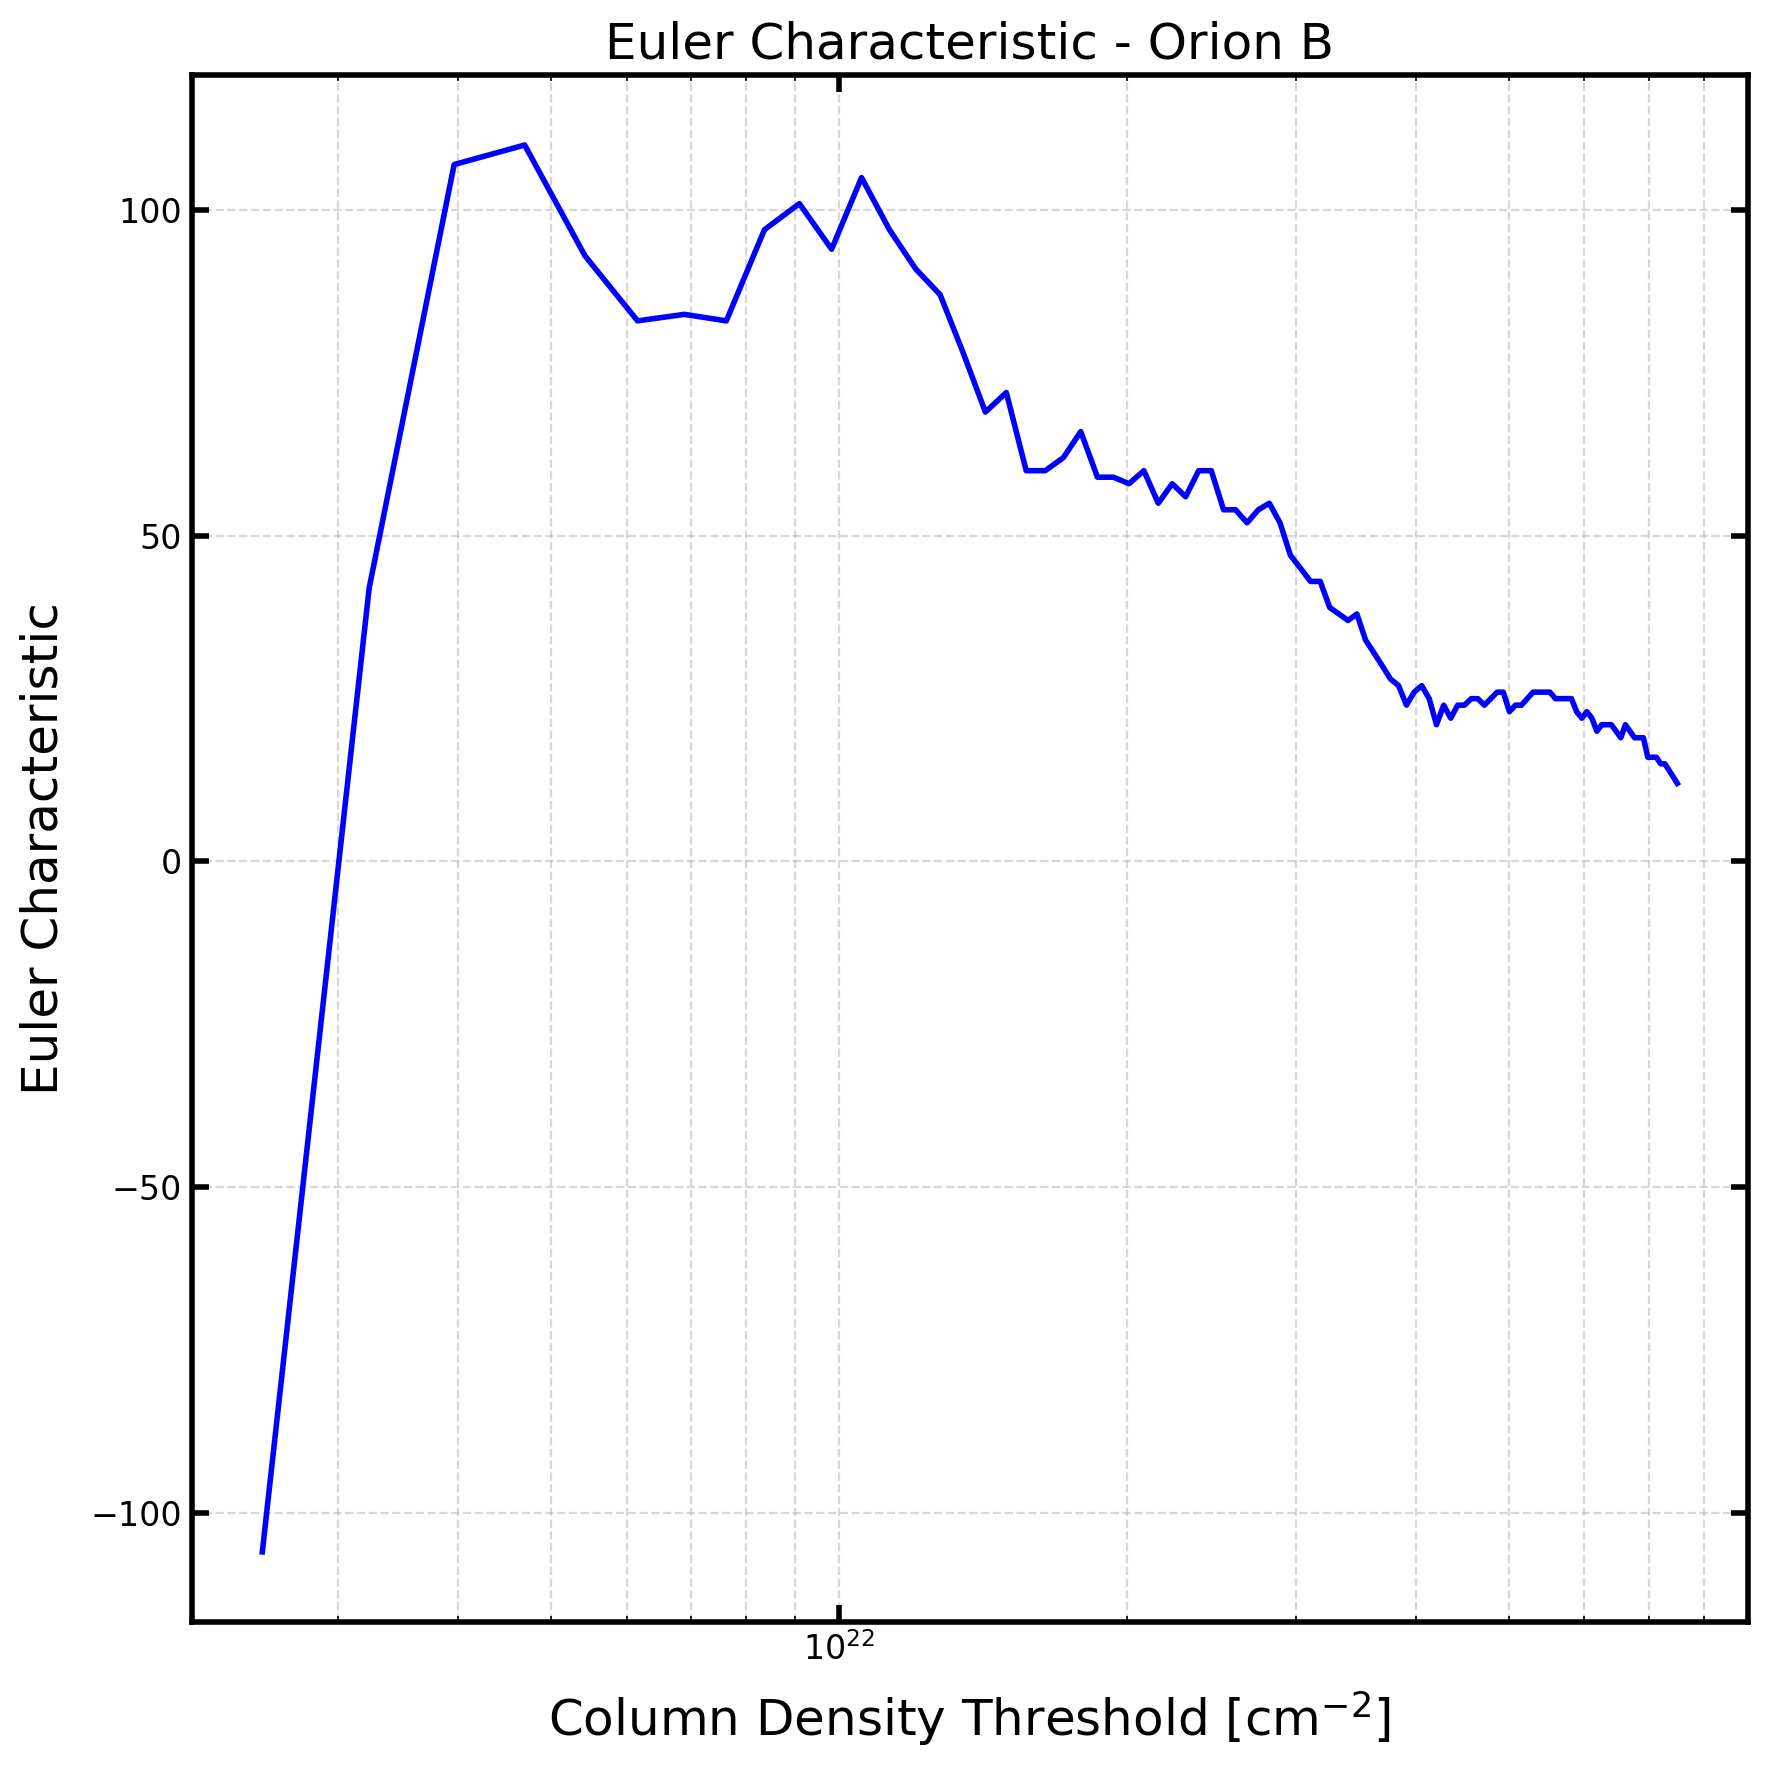

In [9]:
plt.figure(figsize=(9, 9))
# plt.plot(thresholds_OA, results_OA, label="Orion A", color="blue")
plt.plot(thresholds_OA, results_OB, label="Orion B", color="blue")
plt.xscale("log")
plt.xlabel("Column Density Threshold [$\mathrm{cm}^{-2}$]", fontsize=18)
plt.ylabel("Euler Characteristic",  fontsize=18)
plt.title("Euler Characteristic - Orion B", fontsize=18)
# plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15744\3242348380.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


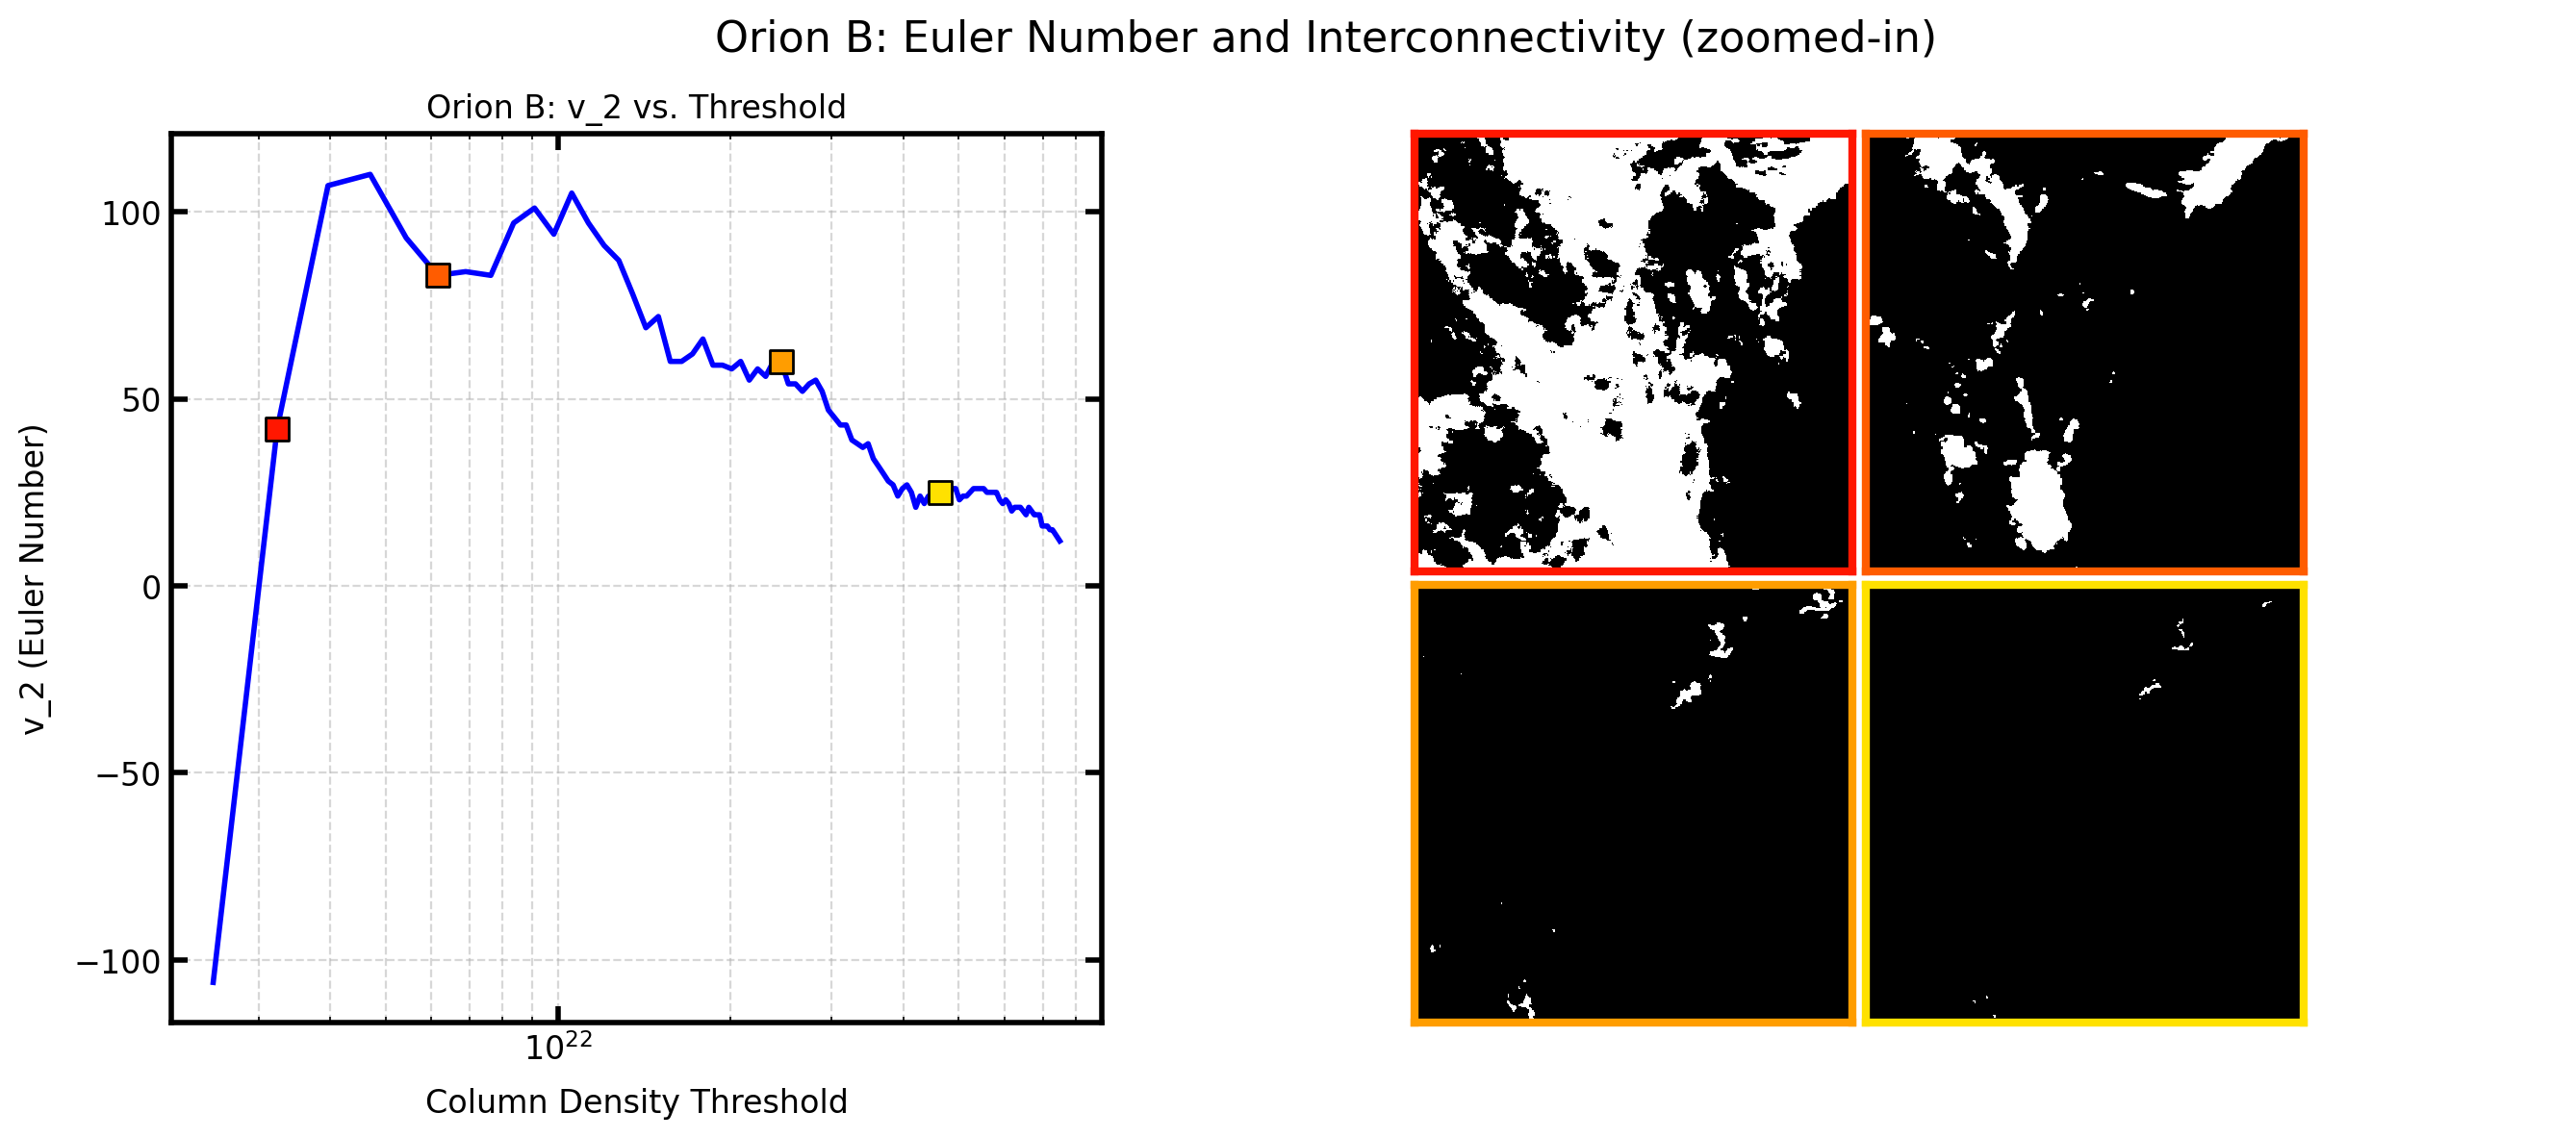

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import ImageGrid

def slice_around_mask_center(mask, zoom_pixels=200):
    """
    Returns a slice around the center of the mask region with a fixed zoom size.
    
    Parameters:
        mask (2D array): Binary mask (e.g., structure >= threshold)
        zoom_pixels (int): Half-width/height of the zoom box in pixels
        
    Returns:
        y_slice, x_slice: slice objects to index the region
    """
    y, x = np.where(mask)
    if len(x) == 0 or len(y) == 0:
        # fallback: center of the full image
        center_y, center_x = mask.shape[0] // 2, mask.shape[1] // 2
    else:
        # center of the structure
        center_y = int(np.mean(y))
        center_x = int(np.mean(x))

    y_min = max(center_y - zoom_pixels, 0)
    y_max = min(center_y + zoom_pixels, mask.shape[0])
    x_min = max(center_x - zoom_pixels, 0)
    x_max = min(center_x + zoom_pixels, mask.shape[1])

    return slice(y_min, y_max), slice(x_min, x_max)


def plot_euler_and_structures(data, thresholds, euler_results, title_prefix, example_threshold_indices, cmap='gray'):
    fig = plt.figure(figsize=(16, 6))

    # Create a gridspec to place the main plot and image grid
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5], wspace=0.05)

    # Left: Euler number vs threshold
    ax_curve = fig.add_subplot(gs[0])
    ax_curve.plot(thresholds, euler_results, color='blue')
    ax_curve.set_xscale("log")
    ax_curve.set_xlabel("Column Density Threshold")
    ax_curve.set_ylabel("v_2 (Euler Number)")
    ax_curve.set_title(f"{title_prefix}: v_2 vs. Threshold")
    ax_curve.grid(True, which="both", ls="--", alpha=0.5)

    # Mark the selected thresholds
    colors = plt.cm.hot(np.linspace(0.4, 0.7, len(example_threshold_indices)))
    for idx, color in zip(example_threshold_indices, colors):
        ax_curve.scatter(thresholds[idx], euler_results[idx], color=color, s=70, edgecolor='black', zorder=5, marker="s")

    # Right: 2x2 grid of structure examples
    ax_grid_container = fig.add_subplot(gs[1])
    ax_grid_container.axis('off')  # Remove container axis

    grid = ImageGrid(fig, gs[1], nrows_ncols=(2, 2), axes_pad=0.07, share_all=True, cbar_mode=None)

    for ax, idx, color in zip(grid, example_threshold_indices, colors):
        mask = data >= thresholds[idx]

        y_slice, x_slice = slice_around_mask_center(mask)

        ax.imshow(mask[y_slice, x_slice], cmap=cmap, origin='lower')
        # ax.imshow(mask, origin='lower', cmap='inferno')
        # ax.set_title(f"Threshold = {thresholds[idx]:.2e}\nEuler = {euler_results[idx]}")
        # Set border color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.suptitle(f"{title_prefix}: Euler Number and Interconnectivity (zoomed-in)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

example_indices_OA = [1, 5, 30, 60]
plot_euler_and_structures(N_H2_OB, thresholds_OA, results_OB, "Orion B", example_indices_OA)


C:\Users\User\AppData\Local\Temp\ipykernel_15744\2796818078.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


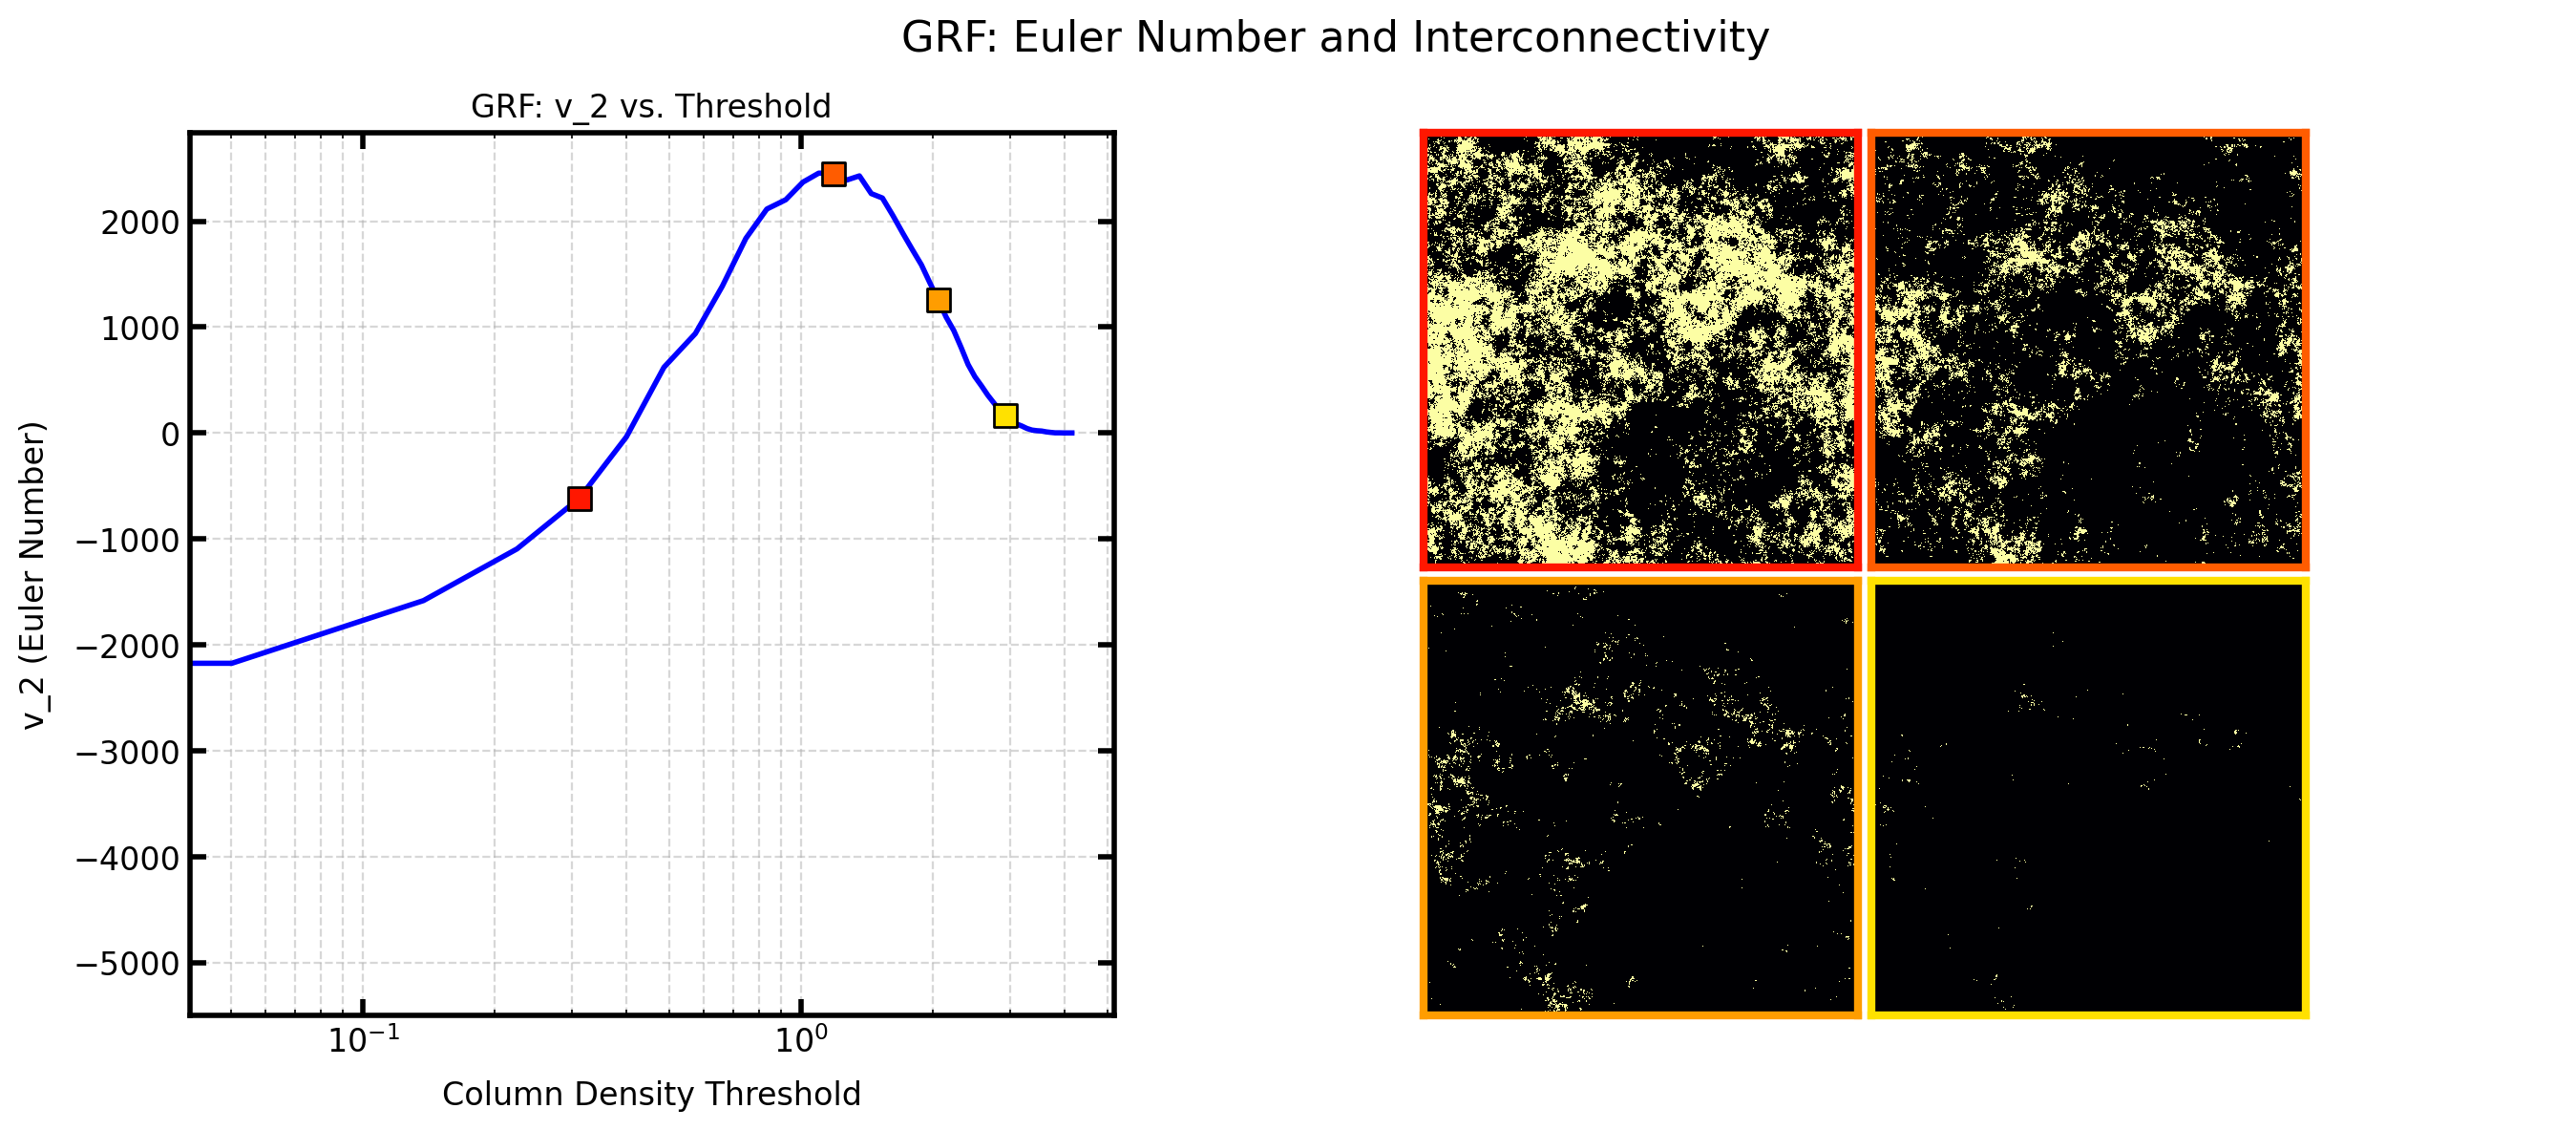

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import ImageGrid

def slice_around_mask_center(mask, zoom_pixels=200):
    """
    Returns a slice around the center of the mask region with a fixed zoom size.
    
    Parameters:
        mask (2D array): Binary mask (e.g., structure >= threshold)
        zoom_pixels (int): Half-width/height of the zoom box in pixels
        
    Returns:
        y_slice, x_slice: slice objects to index the region
    """
    y, x = np.where(mask)
    if len(x) == 0 or len(y) == 0:
        # fallback: center of the full image
        center_y, center_x = mask.shape[0] // 2, mask.shape[1] // 2
    else:
        # center of the structure
        center_y = int(np.mean(y))
        center_x = int(np.mean(x))

    y_min = max(center_y - zoom_pixels, 0)
    y_max = min(center_y + zoom_pixels, mask.shape[0])
    x_min = max(center_x - zoom_pixels, 0)
    x_max = min(center_x + zoom_pixels, mask.shape[1])

    return slice(y_min, y_max), slice(x_min, x_max)


def plot_euler_and_structures(data, thresholds, euler_results, title_prefix, example_threshold_indices, cmap='gray'):
    fig = plt.figure(figsize=(16, 6))

    # Create a gridspec to place the main plot and image grid
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5], wspace=0.05)

    # Left: Euler number vs threshold
    ax_curve = fig.add_subplot(gs[0])
    ax_curve.plot(thresholds, euler_results, color='blue')
    ax_curve.set_xscale("log")
    ax_curve.set_xlabel("Column Density Threshold")
    ax_curve.set_ylabel("v_2 (Euler Number)")
    ax_curve.set_title(f"{title_prefix}: v_2 vs. Threshold")
    ax_curve.grid(True, which="both", ls="--", alpha=0.5)

    # Mark the selected thresholds
    colors = plt.cm.hot(np.linspace(0.4, 0.7, len(example_threshold_indices)))
    for idx, color in zip(example_threshold_indices, colors):
        ax_curve.scatter(thresholds[idx], euler_results[idx], color=color, s=70, edgecolor='black', zorder=5, marker="s")

    # Right: 2x2 grid of structure examples
    ax_grid_container = fig.add_subplot(gs[1])
    ax_grid_container.axis('off')  # Remove container axis

    grid = ImageGrid(fig, gs[1], nrows_ncols=(2, 2), axes_pad=0.07, share_all=True, cbar_mode=None)

    for ax, idx, color in zip(grid, example_threshold_indices, colors):
        mask = data >= thresholds[idx]

        y_slice, x_slice = slice_around_mask_center(mask)

        # ax.imshow(mask[y_slice, x_slice], cmap=cmap, origin='lower')
        ax.imshow(mask, origin='lower', cmap='inferno')
        # ax.set_title(f"Threshold = {thresholds[idx]:.2e}\nEuler = {euler_results[idx]}")
        # Set border color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.suptitle(f"{title_prefix}: Euler Number and Interconnectivity", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

example_indices_OA = [55, 65, 75, 85]
plot_euler_and_structures(GRF, thresholds_GRF, results_GRF, "GRF", example_indices_OA)


C:\Users\User\AppData\Local\Temp\ipykernel_15744\1129551772.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


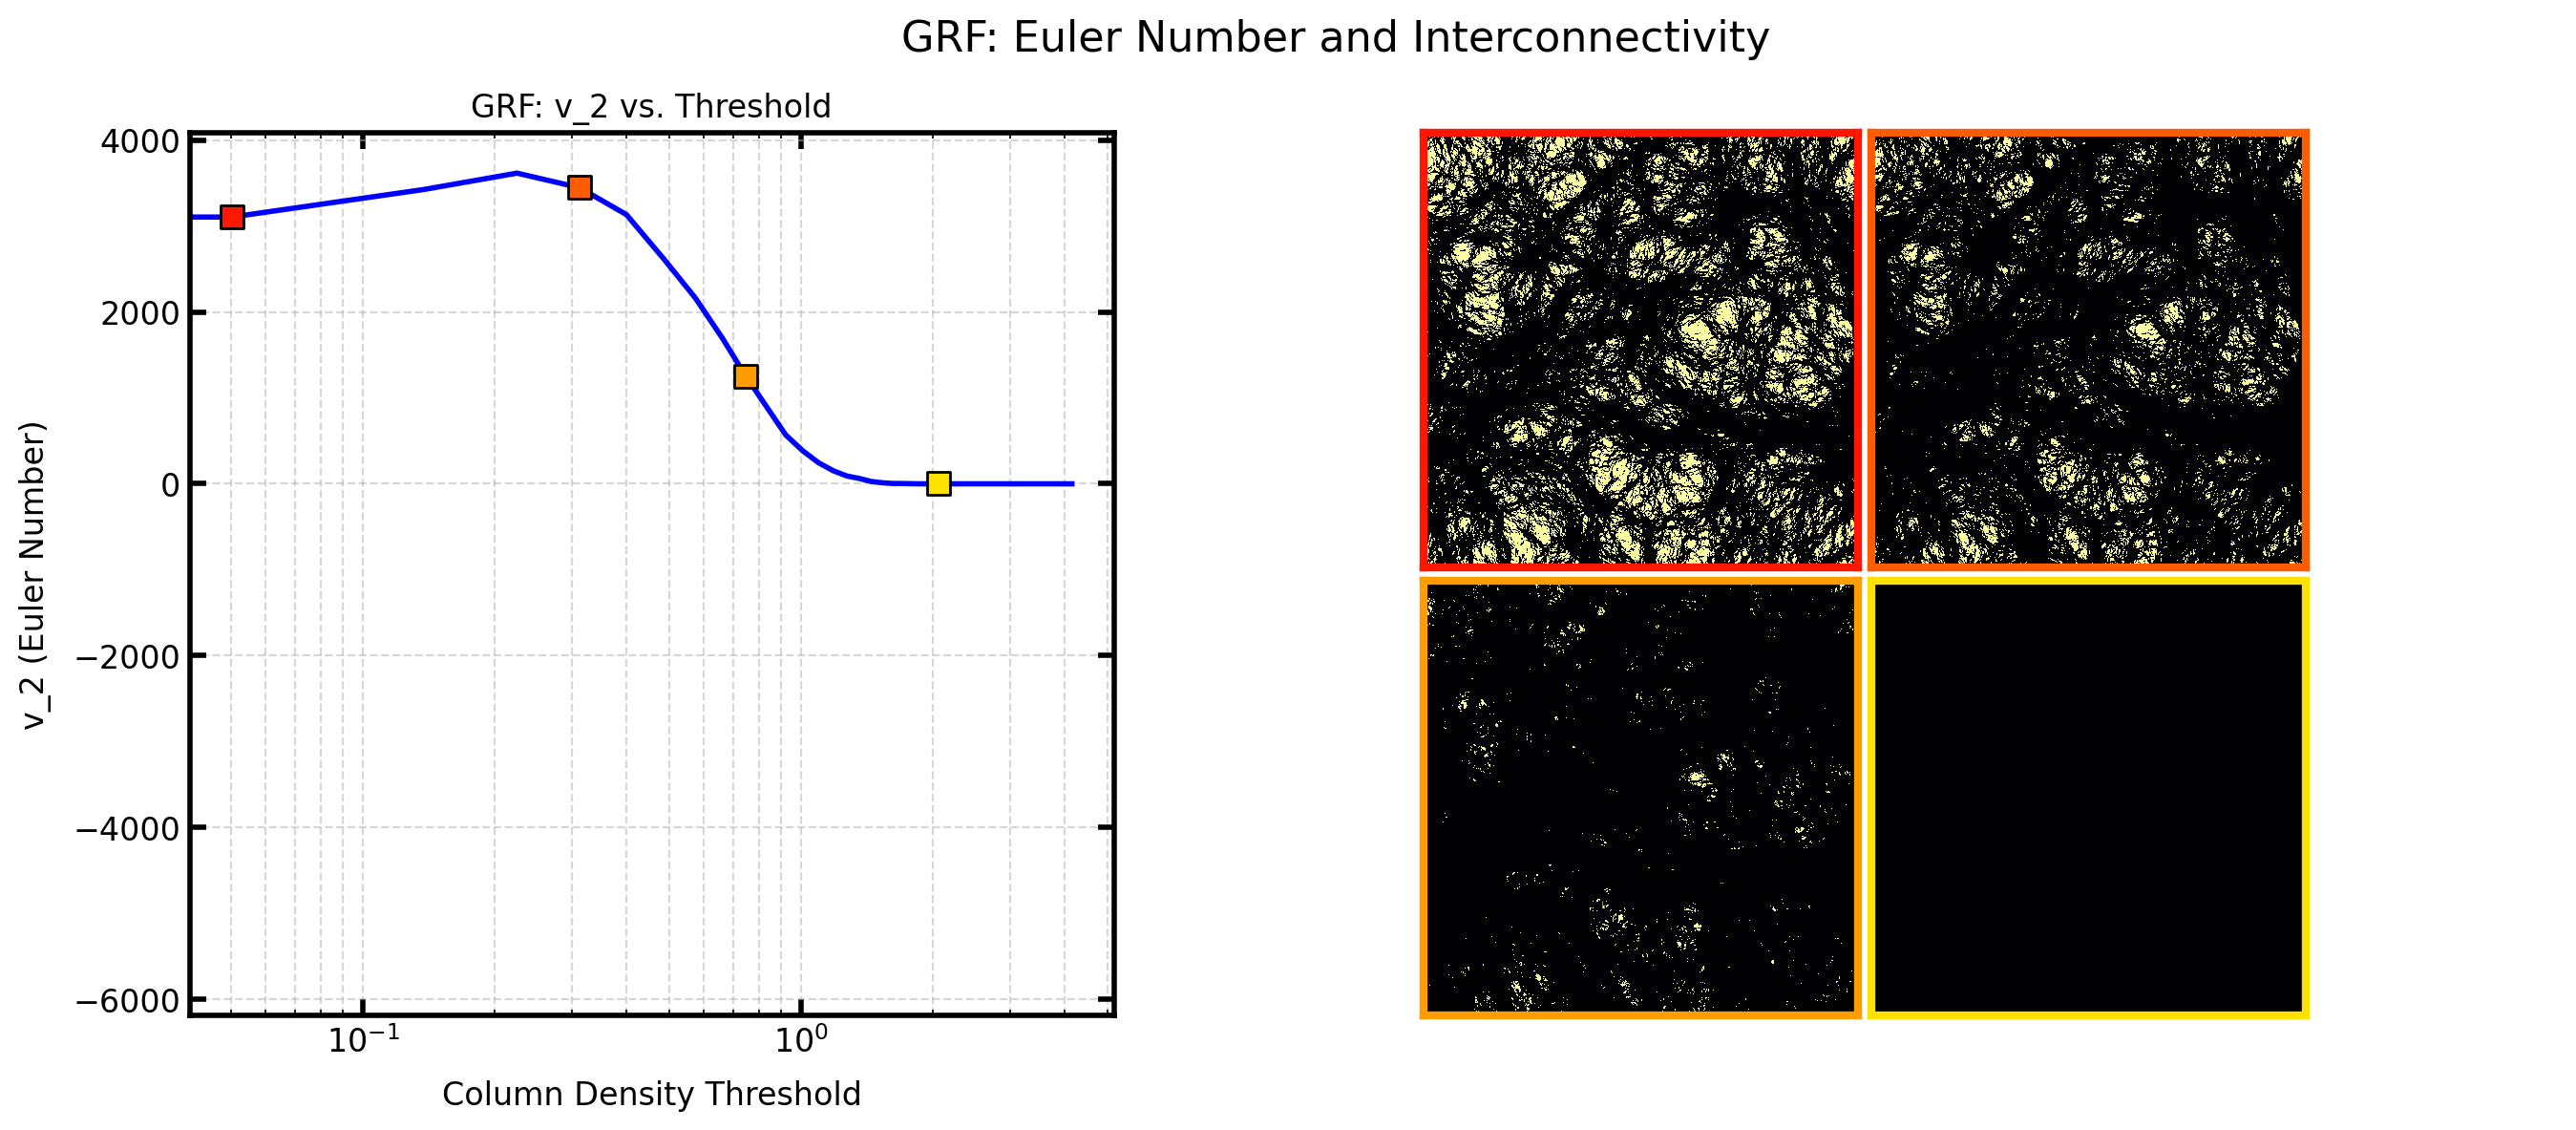

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import ImageGrid

def slice_around_mask_center(mask, zoom_pixels=200):
    """
    Returns a slice around the center of the mask region with a fixed zoom size.
    
    Parameters:
        mask (2D array): Binary mask (e.g., structure >= threshold)
        zoom_pixels (int): Half-width/height of the zoom box in pixels
        
    Returns:
        y_slice, x_slice: slice objects to index the region
    """
    y, x = np.where(mask)
    if len(x) == 0 or len(y) == 0:
        # fallback: center of the full image
        center_y, center_x = mask.shape[0] // 2, mask.shape[1] // 2
    else:
        # center of the structure
        center_y = int(np.mean(y))
        center_x = int(np.mean(x))

    y_min = max(center_y - zoom_pixels, 0)
    y_max = min(center_y + zoom_pixels, mask.shape[0])
    x_min = max(center_x - zoom_pixels, 0)
    x_max = min(center_x + zoom_pixels, mask.shape[1])

    return slice(y_min, y_max), slice(x_min, x_max)


def plot_euler_and_structures(data, thresholds, euler_results, title_prefix, example_threshold_indices, cmap='gray'):
    fig = plt.figure(figsize=(16, 6))

    # Create a gridspec to place the main plot and image grid
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5], wspace=0.05)

    # Left: Euler number vs threshold
    ax_curve = fig.add_subplot(gs[0])
    ax_curve.plot(thresholds, euler_results, color='blue')
    ax_curve.set_xscale("log")
    ax_curve.set_xlabel("Column Density Threshold")
    ax_curve.set_ylabel("v_2 (Euler Number)")
    ax_curve.set_title(f"{title_prefix}: v_2 vs. Threshold")
    ax_curve.grid(True, which="both", ls="--", alpha=0.5)

    # Mark the selected thresholds
    colors = plt.cm.hot(np.linspace(0.4, 0.7, len(example_threshold_indices)))
    for idx, color in zip(example_threshold_indices, colors):
        ax_curve.scatter(thresholds[idx], euler_results[idx], color=color, s=70, edgecolor='black', zorder=5, marker="s")

    # Right: 2x2 grid of structure examples
    ax_grid_container = fig.add_subplot(gs[1])
    ax_grid_container.axis('off')  # Remove container axis

    grid = ImageGrid(fig, gs[1], nrows_ncols=(2, 2), axes_pad=0.07, share_all=True, cbar_mode=None)

    for ax, idx, color in zip(grid, example_threshold_indices, colors):
        mask = data >= thresholds[idx]

        y_slice, x_slice = slice_around_mask_center(mask)

        # ax.imshow(mask[y_slice, x_slice], cmap=cmap, origin='lower')
        ax.imshow(mask, origin='lower', cmap='inferno')
        # ax.set_title(f"Threshold = {thresholds[idx]:.2e}\nEuler = {euler_results[idx]}")
        # Set border color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.suptitle(f"{title_prefix}: Euler Number and Interconnectivity", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

GRF, other_GRF = generate_gaussian_random_field(512, a=-2)
 
other_GRF_results = calculate_v2(other_GRF[:, :, 0], thresholds_GRF)

example_indices_OA = [52, 55, 60, 75]
plot_euler_and_structures(other_GRF[:, :, 0], thresholds_GRF, other_GRF_results, "GRF", example_indices_OA)
